In [84]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score

In [85]:
df = pd.read_csv("cleaned_MH_OC.csv")
print(df.shape)
df.head()

(29942, 161)


,lat_key,fid,latitude,longitude,CLIMATE_VALUE,CLIMATE_SUBCLASS,CLIMATE_CLASS,DOMSOI,SOIL_TYPE,SOIL_SUBCLASS,...,S1_VH_ASM,S1_VH_Energy,S1_VH_MaxProbability,S1_VH_Entropy,S1_VH_GLCM_Mean,S1_VH_GLCM_Variance,S1_VH_GLCM_Correlation,year,month,dayofyear
0,15.709677,48980.0,15.709677,74.047631,2.0,Am,Tropical,Ap,ACRISOLS,Plinthic Acrisols,...,0.699068,0.999988,0.995973,-4.731746,0.022191,0.000029,0.424396,2025,2,48
1,15.709731,48981.0,15.709731,74.048897,2.0,Am,Tropical,Ap,ACRISOLS,Plinthic Acrisols,...,0.636399,0.999990,0.997320,-4.856527,0.016932,0.000098,0.181971,2025,2,48
2,15.711065,48982.0,15.711065,74.047657,2.0,Am,Tropical,Ap,ACRISOLS,Plinthic Acrisols,...,0.606309,0.999960,0.995374,-4.144549,0.013338,0.000111,0.318890,2025,2,48
3,15.804995,48839.5,15.804995,73.733783,2.0,Am,Tropical,Nd,NITOSOLS,Dystric Nitosols,...,0.774612,0.999999,0.998807,-6.255501,0.007464,0.000004,0.314625,2024,3,91
4,15.805012,48835.0,15.805012,73.734112,2.0,Am,Tropical,Nd,NITOSOLS,Dystric Nitosols,...,0.648962,0.999997,0.998350,-5.404119,0.007534,0.000008,1.216725,2024,3,91


In [86]:
target = "OC_group_median"
sample_ids = df['fid']

drop_cols = ['fid',target]
X = df.drop(columns=drop_cols,errors='ignore')
y = df[target]

In [87]:
leakage_cols = [
    'OC',
    'OC_log1p',
    'OC_bin',
    'duplicate_OC_conflict_class'
]

remove_metadata = [
    'fid',
    'date',
    'tile_id',
    'tile_date',
    'source_csv',
    'source_s2_chunk',
    'bare_soil_reason',
    'S2_bare_soil_filter_reason',
    'spatial_qc_reason',
    'village'
]

remove_soil_props = [
    'N','P','K',
    'pH','EC',
    'S','Zn','Fe',
    'Mn','Cu','B',
    'DOMSOI',
    'SOIL_TYPE',
    'SOIL_SUBCLASS'
]

drop_terrain = [
'elev_mean_90m',
'elev_std_90m',
'elev_min_90m',
'elev_max_90m'
]

cols_to_remove = (
    leakage_cols +
    remove_metadata +
    remove_soil_props +
    drop_terrain
)

X = X.drop(
    columns=cols_to_remove,
    errors='ignore'
)

print(X.shape)

(29942, 129)


# Encoding categorical variables

In [88]:
cat_cols = X.select_dtypes(
    include='object'
).columns

print(cat_cols)

Index(['CLIMATE_SUBCLASS', 'CLIMATE_CLASS', 'state', 'district', 'period',
       'LULC_class', 'spatial_qc_status'],
      dtype='str')


/var/folders/lm/z783vpwd6zjfsgvb0mdpm4b80000gn/T/ipykernel_2759/1652557112.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(


In [89]:
for col in cat_cols:
    
    le = LabelEncoder()
    
    X[col] = le.fit_transform(
        X[col].astype(str)
    )

In [90]:
bool_cols = X.select_dtypes(
    include='bool'
).columns

X[bool_cols] = X[
    bool_cols
].astype(int)

In [91]:
terrain_cols = [
'elevation','slope_deg',
'aspect_sin','aspect_cos',
'TWI','flow_acc',
'profile_curvature',
'plan_curvature',
'TPI_300m','TPI_600m',
'SPI','LS_factor'
]

climate_cols = [
'annual_rain_mm',
'R_factor',
'CLIMATE_CLASS',
'CLIMATE_SUBCLASS',
'CLIMATE_VALUE'
]

s2_cols = [
'B2','B3','B4','B5',
'B6','B7','B8',
'B8A','B11','B12',

'NDVI','BSI','NDWI',
'NDBI','SAVI',
'GNDVI','NDMI',
'MSI','NDTI_NBR2',
'MNDWI_Green_SWIR1'
]

s1_cols = [
'S1_VH',
'S1_VV',
'S1_VV_VH',

'S1_VV_Contrast',
'S1_VV_Entropy',

'S1_VH_Contrast',
'S1_VH_Entropy'
]

In [92]:
feature_sets = {

"Terrain":
terrain_cols,

"Terrain_Climate":
terrain_cols +
climate_cols,

"Terrain_Climate_S2":
terrain_cols +
climate_cols +
s2_cols,

"Terrain_Climate_S1_S2":
terrain_cols +
climate_cols +
s1_cols +
s2_cols
}

In [93]:
from sklearn.ensemble import RandomForestRegressor

results = {}

for name, cols in feature_sets.items():

    cols = [
        c for c in cols
        if c in X.columns
    ]

    X_exp = X[cols]

    X_train, X_test, y_train, y_test = train_test_split(
        X_exp,
        y,
        test_size=0.2,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    r2 = r2_score(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    results[name] = [
        len(cols),
        r2,
        rmse
    ]

In [94]:
results_df = pd.DataFrame(
    results,
    index=[
        "Features",
        "R2",
        "RMSE"
    ]
).T

print(
    results_df.sort_values(
        by="R2",
        ascending=False
    )
)

                       Features        R2      RMSE
Terrain_Climate            17.0  0.561220  0.289680
Terrain_Climate_S2         37.0  0.537418  0.297433
Terrain_Climate_S1_S2      44.0  0.534378  0.298409
Terrain                    12.0  0.421768  0.332542


- Satellite features are adding noise to the model
- We have to find a way to reduce the noise

# 1.Keep satellite data based on their feature importance

In [95]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [96]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
)

print(
    importance.head(30)
)

R_factor             0.203876
annual_rain_mm       0.198558
elevation            0.090036
TPI_600m             0.024203
TPI_300m             0.021663
NDTI_NBR2            0.021250
S1_VV                0.020369
S1_VV_VH             0.018998
S1_VH                0.018515
TWI                  0.018006
S1_VH_Entropy        0.017732
BSI                  0.016325
flow_acc             0.015931
NDVI                 0.015689
plan_curvature       0.015508
S1_VV_Entropy        0.015194
B2                   0.014989
MNDWI_Green_SWIR1    0.014933
profile_curvature    0.014082
S1_VV_Contrast       0.013964
B12                  0.013738
aspect_sin           0.013043
LS_factor            0.012490
B11                  0.012392
SAVI                 0.012277
aspect_cos           0.011774
SPI                  0.011322
S1_VH_Contrast       0.010907
B3                   0.010457
B5                   0.010312
dtype: float64


In [97]:
top_satellite = importance[
    importance.index.isin(
        s2_cols + s1_cols
    )
].head(10)

top_sat_cols = top_satellite.index.tolist()

print(top_sat_cols)

sat_importance = importance[
    importance.index.isin(
        s2_cols + s1_cols
    )
]

sat_importance = sat_importance.sort_values(
    ascending=False
)

print(
    sat_importance.head(20)
)

['NDTI_NBR2', 'S1_VV', 'S1_VV_VH', 'S1_VH', 'S1_VH_Entropy', 'BSI', 'NDVI', 'S1_VV_Entropy', 'B2', 'MNDWI_Green_SWIR1']
NDTI_NBR2            0.021250
S1_VV                0.020369
S1_VV_VH             0.018998
S1_VH                0.018515
S1_VH_Entropy        0.017732
BSI                  0.016325
NDVI                 0.015689
S1_VV_Entropy        0.015194
B2                   0.014989
MNDWI_Green_SWIR1    0.014933
S1_VV_Contrast       0.013964
B12                  0.013738
B11                  0.012392
SAVI                 0.012277
S1_VH_Contrast       0.010907
B3                   0.010457
B5                   0.010312
NDWI                 0.009827
GNDVI                0.009732
B8                   0.009547
dtype: float64


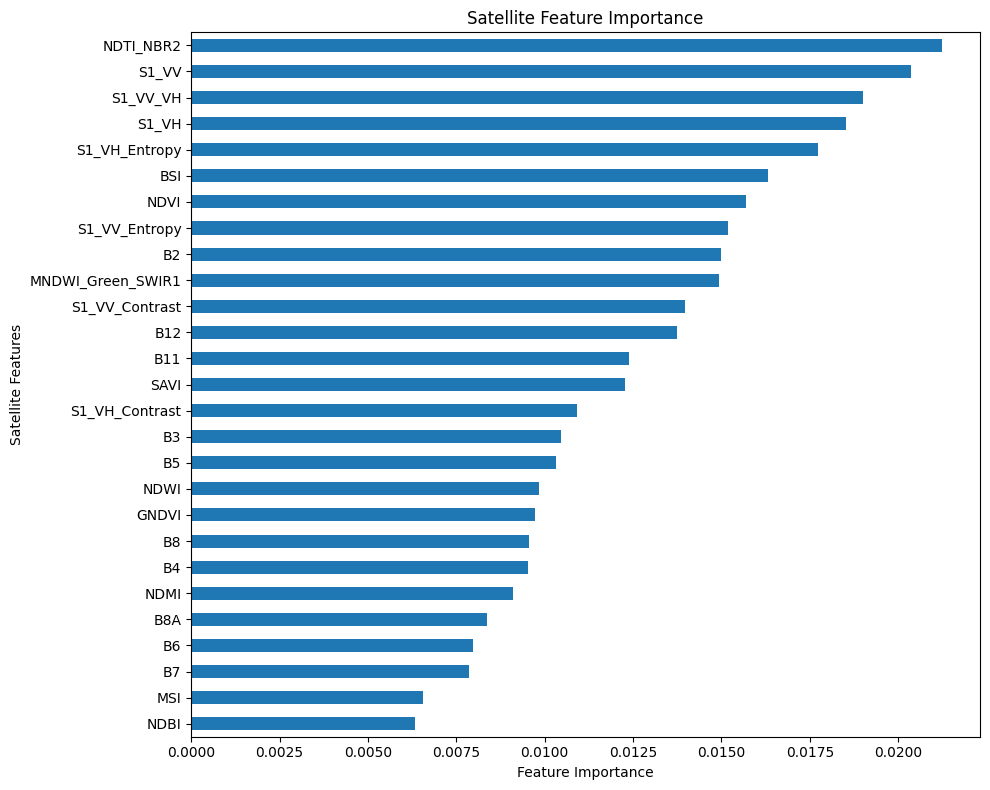

In [98]:
plt.figure(
    figsize=(10,8)
)

sat_importance.sort_values().plot(
    kind='barh'
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Satellite Features"
)

plt.title(
    "Satellite Feature Importance"
)

plt.tight_layout()

plt.show()

In [ ]:
top_sat_cols = sat_importance.head(
    15
).index.tolist()
final_cols = (
    terrain_cols +
    climate_cols +
    top_sat_cols
)

In [101]:
final_cols = list(
    set(final_cols)
)

In [103]:
final_cols = [

    col for col in final_cols

    if col in X.columns
]

In [104]:
X_final = X[
    final_cols
]

print(
    X_final.shape
)

(29942, 32)


In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=42
)

In [106]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [107]:
pred = model.predict(
    X_test
)

print(
    "R2:",
    r2_score(
        y_test,
        pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )
)

R2: 0.5409457532481712
RMSE: 0.2962968561521344


# 2.Apply PCA on Satellite data

In [68]:
sat_cols = [

col for col in X.columns

if (
    
    col in s1_cols
    
    or
    
    col in s2_cols
)
]

print(
    len(sat_cols)
)

27


In [69]:
X_sat = X[
    sat_cols
]

X_other = X.drop(
    columns=sat_cols
)

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_sat_scaled = scaler.fit_transform(
    X_sat
)

In [71]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=0.95
)

X_sat_pca = pca.fit_transform(
    X_sat_scaled
)

print(
    X_sat.shape
)

print(
    X_sat_pca.shape
)

(29942, 27)
(29942, 10)


In [72]:
pca_cols = [

f"SAT_PC_{i}"

for i in range(
    X_sat_pca.shape[1]
)
]

X_sat_pca_df = pd.DataFrame(

    X_sat_pca,

    columns=pca_cols,

    index=X.index
)

In [73]:
X_final = pd.concat(

    [
        X_other,

        X_sat_pca_df
    ],

    axis=1
)

print(
    X_final.shape
)

(29942, 112)


In [74]:
X_train, X_test, y_train, y_test = train_test_split(

    X_final,

    y,

    test_size=0.2,

    random_state=42
)

model.fit(
    X_train,
    y_train
)

r2 = r2_score(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

print(
    "R2:",
    r2
)

print(
    "RMSE:",
    rmse
)

R2: 0.5399467743132722
RMSE: 0.29661907674103194


# Feature importance

In [75]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
)

print(
    importance
)

annual_rain_mm                      0.170573
R_factor                            0.154224
district                            0.100769
longitude                           0.067795
lat_key                             0.050802
latitude                            0.047988
elevation                           0.024637
dayofyear                           0.024033
cloud_cover                         0.018386
days_from_sample                    0.016853
TPI_600m                            0.012287
S1_VV_GLCM_Correlation              0.010463
S1_VV_ASM                           0.008826
SAT_PC_6                            0.008547
S1_VH_GLCM_Correlation              0.008514
S1_VH_ASM                           0.007907
SAT_PC_7                            0.006876
SAT_PC_2                            0.006837
SAT_PC_9                            0.006796
RI                                  0.006703
MCARI                               0.006536
S1_VH_VV                            0.006326
plan_curva

In [76]:
pd.set_option(
    'display.max_rows',
    None
)

print(
    importance
)

annual_rain_mm                      0.170573
R_factor                            0.154224
district                            0.100769
longitude                           0.067795
lat_key                             0.050802
latitude                            0.047988
elevation                           0.024637
dayofyear                           0.024033
cloud_cover                         0.018386
days_from_sample                    0.016853
TPI_600m                            0.012287
S1_VV_GLCM_Correlation              0.010463
S1_VV_ASM                           0.008826
SAT_PC_6                            0.008547
S1_VH_GLCM_Correlation              0.008514
S1_VH_ASM                           0.007907
SAT_PC_7                            0.006876
SAT_PC_2                            0.006837
SAT_PC_9                            0.006796
RI                                  0.006703
MCARI                               0.006536
S1_VH_VV                            0.006326
plan_curva

In [77]:
importance_df = pd.DataFrame({

    "Feature": importance.index,

    "Importance": importance.values

})

print(
    importance_df
)

                              Feature  Importance
0                      annual_rain_mm    0.170573
1                            R_factor    0.154224
2                            district    0.100769
3                           longitude    0.067795
4                             lat_key    0.050802
5                            latitude    0.047988
6                           elevation    0.024637
7                           dayofyear    0.024033
8                         cloud_cover    0.018386
9                    days_from_sample    0.016853
10                           TPI_600m    0.012287
11             S1_VV_GLCM_Correlation    0.010463
12                          S1_VV_ASM    0.008826
13                           SAT_PC_6    0.008547
14             S1_VH_GLCM_Correlation    0.008514
15                          S1_VH_ASM    0.007907
16                           SAT_PC_7    0.006876
17                           SAT_PC_2    0.006837
18                           SAT_PC_9    0.006796


In [78]:
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

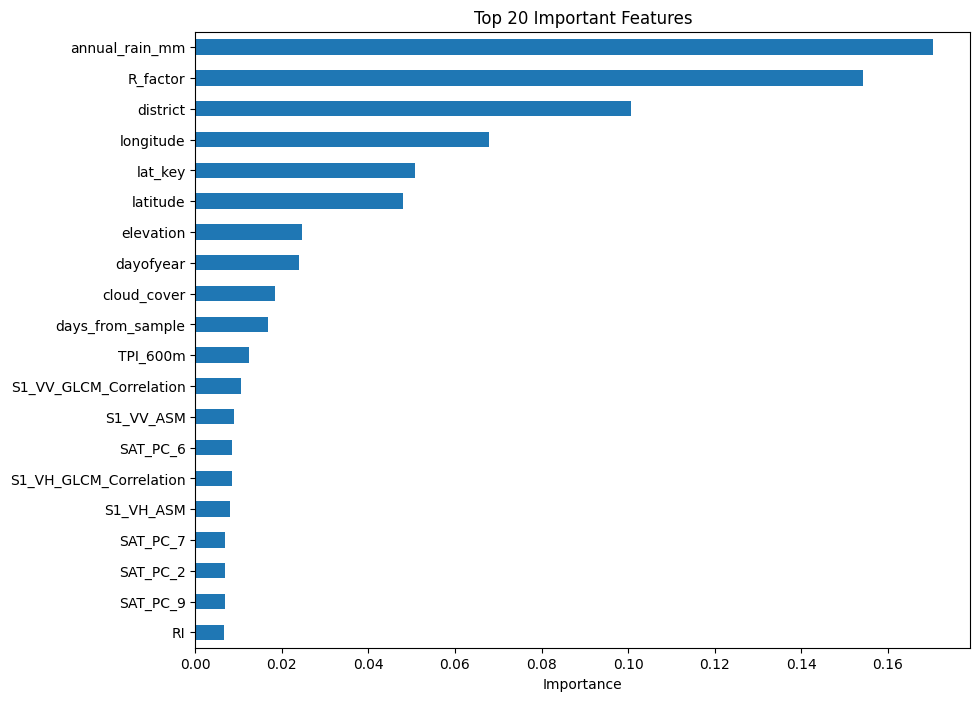

In [79]:
top20 = importance.sort_values(
    ascending=False
).head(20)

plt.figure(
    figsize=(10,8)
)

top20.sort_values().plot(
    kind='barh'
)

plt.xlabel(
    "Importance"
)

plt.title(
    "Top 20 Important Features"
)

plt.show()

In [80]:
print(
    importance.head(20)
)

annual_rain_mm            0.170573
R_factor                  0.154224
district                  0.100769
longitude                 0.067795
lat_key                   0.050802
latitude                  0.047988
elevation                 0.024637
dayofyear                 0.024033
cloud_cover               0.018386
days_from_sample          0.016853
TPI_600m                  0.012287
S1_VV_GLCM_Correlation    0.010463
S1_VV_ASM                 0.008826
SAT_PC_6                  0.008547
S1_VH_GLCM_Correlation    0.008514
S1_VH_ASM                 0.007907
SAT_PC_7                  0.006876
SAT_PC_2                  0.006837
SAT_PC_9                  0.006796
RI                        0.006703
dtype: float64


# Spatial CV 

In [81]:
from sklearn.cluster import KMeans

coords = df[
    ['latitude','longitude']
]

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

spatial_groups = kmeans.fit_predict(
    coords
)

In [82]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(
    n_splits=5
)

In [83]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np

r2_scores = []

rmse_scores = []

for train_idx, test_idx in gkf.split(
    X_final,
    y,
    groups=spatial_groups
):

    X_train = X_final.iloc[
        train_idx
    ]

    X_test = X_final.iloc[
        test_idx
    ]

    y_train = y.iloc[
        train_idx
    ]

    y_test = y.iloc[
        test_idx
    ]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    r2_scores.append(

        r2_score(
            y_test,
            pred
        )
    )

    rmse_scores.append(

        np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        )
    )

KeyboardInterrupt: 

In [ ]:
print(
    "Spatial CV R2:",
    np.mean(
        r2_scores
    )
)

print(
    "Spatial CV RMSE:",
    np.mean(
        rmse_scores
    )
)

print(
    "Fold R2:",
    r2_scores
)

Spatial CV R2: -0.36012240101906806
Spatial CV RMSE: 0.3736067880286844
Fold R2: [0.3592174440523034, 0.16422068691366587, -0.35618031825298013, 0.13931621899516689, -2.1071860368034963]


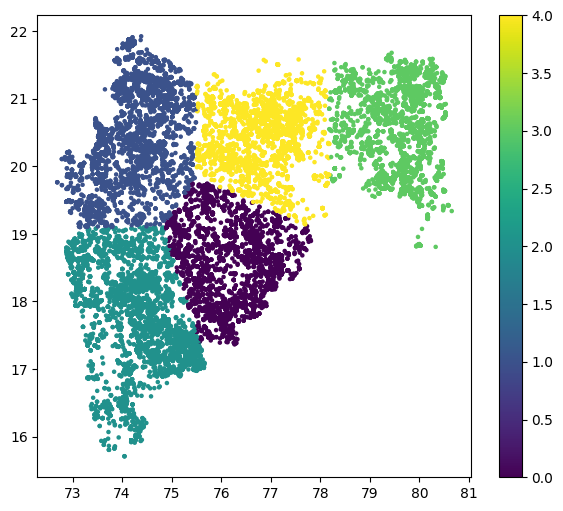

In [ ]:
plt.figure(
    figsize=(7,6)
)

plt.scatter(

    df['longitude'],

    df['latitude'],

    c=spatial_groups,

    s=5
)

plt.colorbar()

plt.show()